In [1]:
##################################################################### 
#1. Data Preprocessing
######################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. 데이터셋 활용 및 삭제 (Drop)
# =====================================================================
df = pd.read_csv('Clean_Dataset.csv')

# [피드백 1번 반영] 과적합을 유발하는 편명(flight)과 불필요한 인덱스 삭제
columns_to_drop = []
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')
if 'flight' in df.columns:
    columns_to_drop.append('flight')
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# =====================================================================
# 3. 변수 생성 (Feature Engineering)
# =====================================================================
# ① 노선(Route) 변수 생성: 출발지_도착지
df['route'] = df['source_city'] + "_" + df['destination_city']

# ② 예약 시점 구간 변수 생성
# [피드백 2번 반영] -1부터 시작하여 0일 데이터 손실(결측치) 완벽 방지
bins = [-1, 7, 21, df['days_left'].max()]
labels = ['1~7일 전(출발 직전)', '8~21일 전(단기)', '22일 이상(장기)']
df['booking_period'] = pd.cut(df['days_left'], bins=bins, labels=labels)

# ③ 타겟 변수 로그 변환 (가격 변동성 학습 최적화)
df['price'] = np.log1p(df['price'])


# =====================================================================
# 2. 숫자로 변환 (Encoding)
# =====================================================================
# ① class (절대 지우지 않고 0과 1로 매핑)
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

# ② stops: 직항 0, 1회 경유 1, 2회 이상 2
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# ③ 도시 이름 원-핫 인코딩 (6개 도시 분할)
df = pd.get_dummies(df, columns=['source_city', 'destination_city'])


# =====================================================================
# 4. 데이터 분리 (Train/Test Split - 8:2 비율)
# =====================================================================
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== 최종 전처리 및 데이터 분리 완료 ===")
print(f"X_train 데이터 크기: {X_train.shape}")
print(f"y_train 데이터 크기: {y_train.shape}")
# =====================================================================
# 5. CSV 파일로 저장하기 (눈으로 확인하기 위한 용도)
# =====================================================================

# 1. 전체 전처리 완료된 데이터 하나로 저장하기
df.to_csv('final_preprocessed_data.csv', index=False, encoding='utf-8-sig')

# 2. (선택사항) 머신러닝용으로 분리된 Train / Test 데이터를 각각 저장하기
# 정답(y) 컬럼을 다시 붙여서 보기 좋게 하나의 파일로 만듭니다.
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_data.csv', index=False, encoding='utf-8-sig')

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('test_data.csv', index=False, encoding='utf-8-sig')

print("CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.")


=== 최종 전처리 및 데이터 분리 완료 ===
X_train 데이터 크기: (240122, 21)
y_train 데이터 크기: (240122,)
CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.


In [2]:
##################################################################### 
# *** 다시 전처리 요청 
######################################################################

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. 남은 범주형 변수들 원-핫 인코딩 (X_train, X_test 동일하게 적용)
# 현재 X에는 'airline', 'departure_time', 'arrival_time', 'route', 'booking_period'가 문자열입니다.
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# 훈련 데이터와 테스트 데이터의 컬럼 순서를 맞추는 작업 (중요)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


In [4]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 15.0 MB/s  0:00:00


In [6]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. LightGBM 전용 분석 함수 정의
def get_lgbm_results(target_df, label):
    # 트리 모델은 원-핫 인코딩보다 Label Encoding이나 원-핫을 써도 되지만, 
    # 여기서는 기존과 동일하게 get_dummies를 사용하겠습니다.
    X = pd.get_dummies(target_df.drop(columns=['price', 'class']))
    y = target_df['price']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # [참고] LightGBM은 StandardScaler가 필수가 아닙니다! (트리 모델의 장점)
    
    # 2. 모델 생성 및 학습
    # 하이퍼파라미터는 가장 기본적이면서 성능이 잘 나오는 세팅입니다.
    model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=31, random_state=42)
    model.fit(X_train, y_train)
    
    # 3. 예측 및 평가
    y_pred = model.predict(X_test)
    
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
    
    # 중요도(Feature Importance) 추출
    importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
    
    print(f"--- {label} LightGBM 결과 ---")
    print(f"R2: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}\n")
    
    return r2, mae, rmse, importances

# 2. 실행
lgbm_eco_r2, lgbm_eco_mae, lgbm_eco_rmse, lgbm_eco_imp = get_lgbm_results(df[df['class'] == 0], "Economy")
lgbm_bus_r2, lgbm_bus_mae, lgbm_bus_rmse, lgbm_bus_imp = get_lgbm_results(df[df['class'] == 1], "Business")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 434
[LightGBM] [Info] Number of data points in the train set: 165332, number of used features: 66
[LightGBM] [Info] Start training from score 8.650828
--- Economy LightGBM 결과 ---
R2: 0.8747, MAE: 903.18, RMSE: 1579.28

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 426
[LightGBM] [Info] Number of data points in the train set: 74789, number of used features: 62
[LightGBM] [In

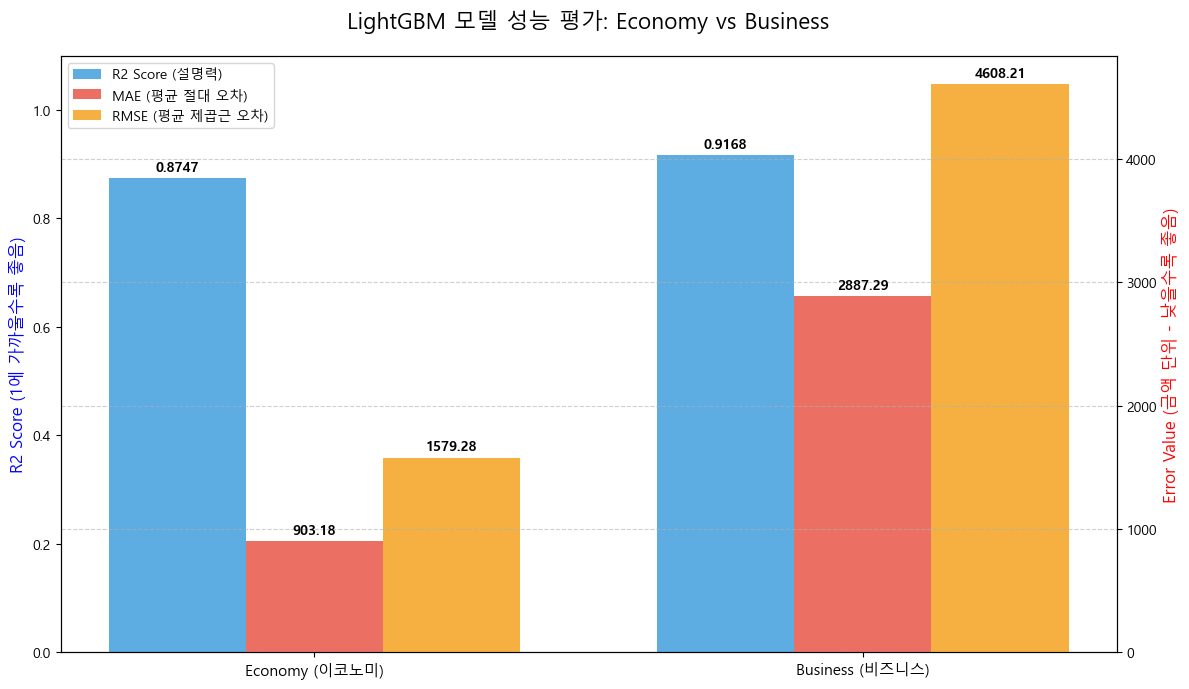

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. LightGBM 결과 데이터 정의 (출력된 결과값 입력)
labels = ['Economy (이코노미)', 'Business (비즈니스)']
r2_vals = [0.8747, 0.9168]
mae_vals = [903.18, 2887.29]
rmse_vals = [1579.28, 4608.21]

x = np.arange(len(labels))  # 라벨 위치
width = 0.25  # 막대 너비

# 3. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 왼쪽 축: 결정계수 (R2 Score) ---
rects1 = ax1.bar(x - width, r2_vals, width, label='R2 Score (설명력)', color='#3498db', alpha=0.8)
ax1.set_ylabel('R2 Score (1에 가까울수록 좋음)', color='blue', fontsize=12)
ax1.set_ylim(0, 1.1)  # 1.0 이상으로 여유 있게 설정
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)

# --- 오른쪽 축: 오차 지표 (MAE, RMSE) ---
ax2 = ax1.twinx()
rects2 = ax2.bar(x, mae_vals, width, label='MAE (평균 절대 오차)', color='#e74c3c', alpha=0.8)
rects3 = ax2.bar(x + width, rmse_vals, width, label='RMSE (평균 제곱근 오차)', color='#f39c12', alpha=0.8)
ax2.set_ylabel('Error Value (금액 단위 - 낮을수록 좋음)', color='red', fontsize=12)

# 4. 수치 표시 (막대 위에 숫자 쓰기)
def autolabel(rects, ax, is_r2=False):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}' if not is_r2 else f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3포인트 위로
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1, ax1, is_r2=True)
autolabel(rects2, ax2)
autolabel(rects3, ax2)

# 5. 제목 및 범례
plt.title('LightGBM 모델 성능 평가: Economy vs Business', fontsize=16, pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

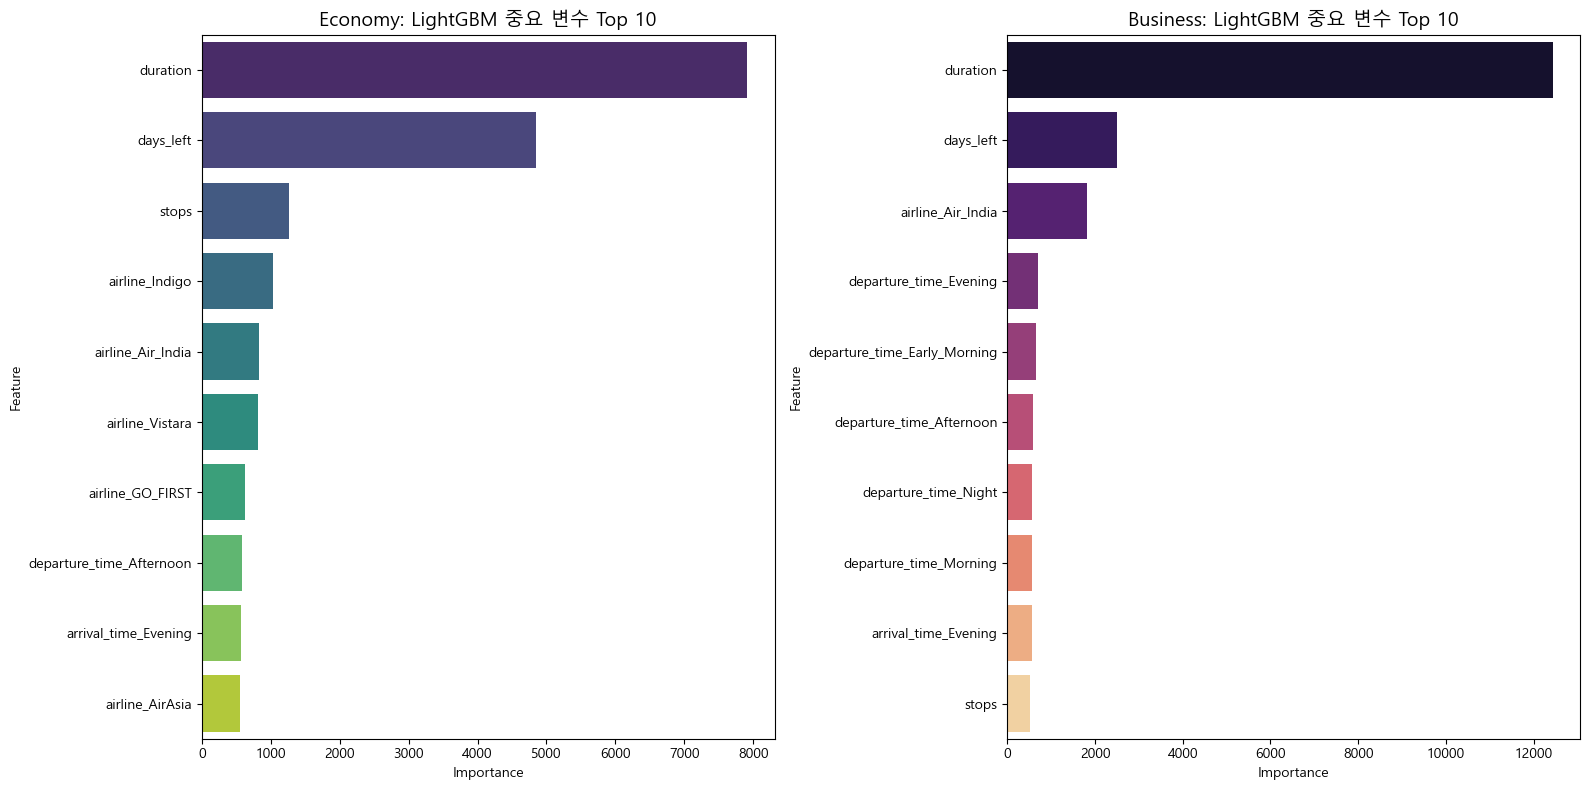

In [14]:
# LightGBM 중요도 시각화 (Ridge 결과와 비교용)
plt.figure(figsize=(16, 8))

# Economy 중요도 Top 10
plt.subplot(1, 2, 1)
eco_top = lgbm_eco_imp.sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=eco_top, hue='Feature', palette='viridis', legend=False)
plt.title('Economy: LightGBM 중요 변수 Top 10', fontsize=14)

# Business 중요도 Top 10
plt.subplot(1, 2, 2)
bus_top = lgbm_bus_imp.sort_values(by='Importance', ascending=False).head(10)
sns.barplot(x='Importance', y='Feature', data=bus_top, hue='Feature', palette='magma', legend=False)
plt.title('Business: LightGBM 중요 변수 Top 10', fontsize=14)

plt.tight_layout()
plt.show()

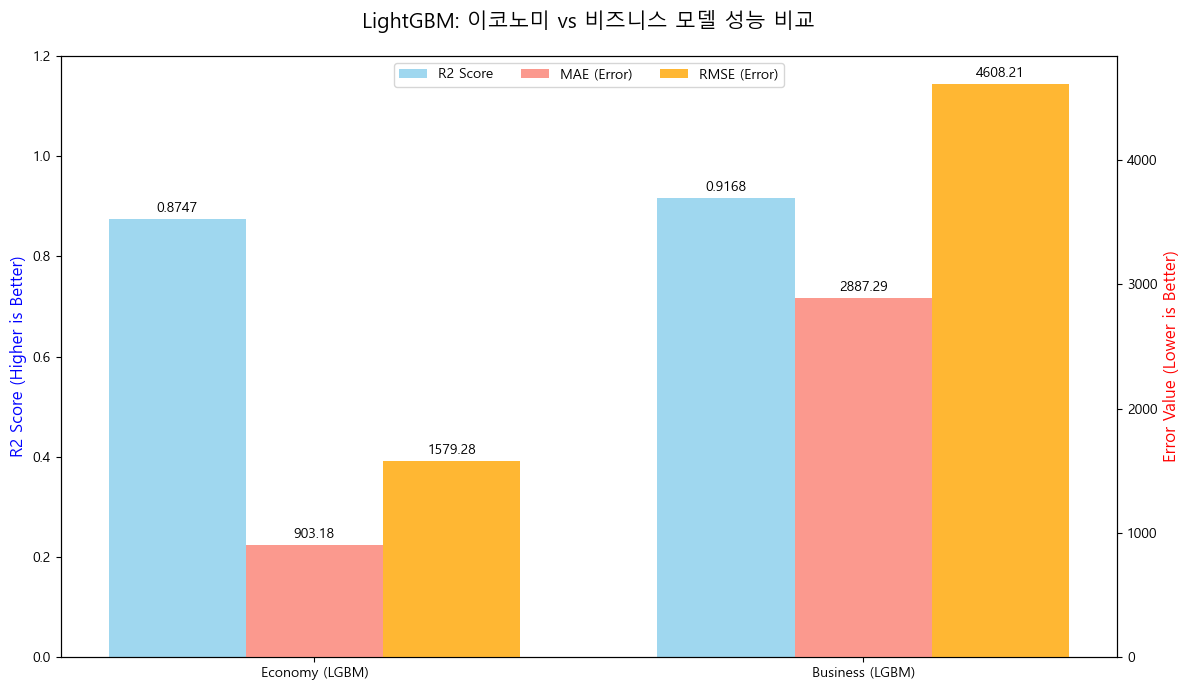

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 정의 (LightGBM 결과 변수들 사용)
labels = ['Economy (LGBM)', 'Business (LGBM)']
# 위에서 계산된 lgbm_... 변수들을 리스트로 묶습니다.
r2_vals = [lgbm_eco_r2, lgbm_bus_r2]
mae_vals = [lgbm_eco_mae, lgbm_bus_mae]
rmse_vals = [lgbm_eco_rmse, lgbm_bus_rmse]

# 3. 도화지(Figure)와 축(Axes) 생성
fig, ax1 = plt.subplots(figsize=(12, 7))
x = np.arange(len(labels))
width = 0.25 

# 4. R2 Score 그리기 (왼쪽 축 - 파란색 계열)
rects1 = ax1.bar(x - width, r2_vals, width, label='R2 Score', color='skyblue', alpha=0.8)
ax1.set_ylabel('R2 Score (Higher is Better)', color='blue', fontsize=12)
ax1.set_ylim(0, 1.2) # 범례 공간 확보
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# 5. MAE & RMSE 그리기 (오른쪽 축 - 붉은색/오렌지색 계열)
# MAE와 RMSE는 '오차'이므로 축을 공유하며 나란히 배치합니다.
ax2 = ax1.twinx()
rects2 = ax2.bar(x, mae_vals, width, label='MAE (Error)', color='salmon', alpha=0.8)
rects3 = ax2.bar(x + width, rmse_vals, width, label='RMSE (Error)', color='orange', alpha=0.8)
ax2.set_ylabel('Error Value (Lower is Better)', color='red', fontsize=12)

# 6. 디자인 및 범례 설정
plt.title('LightGBM: 이코노미 vs 비즈니스 모델 성능 비교', fontsize=15, pad=20)

# 두 축의 범례를 하나로 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=3)

# 막대 위에 수치 표시 (선택사항)
def autolabel(rects, ax, is_r2=False):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}' if not is_r2 else f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1, ax1, is_r2=True)
autolabel(rects2, ax2)
autolabel(rects3, ax2)

plt.tight_layout()
plt.savefig('lgbm_performance_comparison.png') # 파일 저장
plt.show()